In [9]:
from pathlib import Path
import matplotlib.pyplot as plt
import math
from dataclasses import dataclass, field
from copy import deepcopy
import itertools
from operator import attrgetter as attrg
import functools
import cv2
import numpy as np

In [2]:
DS = Path("../../../datasets")
BLUR_DS = DS / "blur"
HIT = BLUR_DS / "imgs-with-distances" / "hit"

IMG_ROOT = HIT / "10x4"

In [ ]:
def resize(img, w, interpolation):
    new_width = w
    aspect_ratio = new_width / img.shape[1]
    new_height = int(img.shape[0] * aspect_ratio)
    return cv2.resize(img, (new_width, new_height), interpolation=interpolation)


def _get_tlrb(img, bb):
    t, l = bb.y0, bb.x0
    b, r = img.shape[0] - bb.y1, img.shape[1] - bb.x1
    return t, l, r, b


# The standard resize when run on the first example of hit bug sprays was not enough.
# The standard resize works on the entire image.
# So I’ve been taking random crops of images and passing them to resize.
# The new algorithm gets the bounding box of each object and
# finds the dimensions of the source object's crop that need to be resized
# to match the target crop's shape.
# For this, I would just find the resize ratio for the actual bounding boxes. We are using the width here for resizing.
# Then we find how much padding we need in the source box, which depends on the padding in the target image and the resizing padding.
# Once we have that, we get the crop that needs to be resized to the target image size.
# We resize that crop using standard CV2 resize, preserving the aspect ratio between the source and target crops.
def resize_with_bboxes(src, src_bbox, target, target_bbox, interpolation):
    # the bounded box in src is resized to bounded box in target
    alpha = target_bbox.w / src_bbox.w
    t, l, r, b = _get_tlrb(target, target_bbox)
    t1, l1, r1, b1 = t / alpha, l / alpha, r / alpha, b / alpha

    y0 = int(max(src_bbox.y0 - t1, 0))
    x0 = int(max(src_bbox.x0 - l1, 0))
    y1 = int(min(src_bbox.y1 + b1, src.shape[0]))
    x1 = int(min(src_bbox.x1 + r1, src.shape[1]))

    crop_to_resize = src[y0:y1, x0:x1]

    return resize(crop_to_resize, target.shape[1], interpolation)


def add_luminosity_lab(rgb, add_constant):
    lab_rsz = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    lab_rsz[:, :, 0] = np.clip(
        lab_rsz[:, :, 0].astype(np.int16) + add_constant, 0, 255
    ).astype(np.uint8)
    return cv2.cvtColor(lab_rsz, cv2.COLOR_LAB2RGB)


def show(crops, figsize=None, ncols=2):
    crops = list(crops)
    crops = [c.rgb if isinstance(c, ImageAndDist) else c for c in crops]
    rows = math.ceil(len(crops) / ncols)
    if figsize is None:
        figsize = (5 * rows, 5 * rows)
        print("figsize", figsize)
    _, axs = plt.subplots(rows, ncols, figsize=figsize)
    axs = axs.flatten()
    for i, c in enumerate(crops):
        axs[i].imshow(c)
    plt.tight_layout()
    plt.show()


def sobel_edge_detection(img_rgb):
    # Load the image in grayscale
    # Compute the 1st order Sobel derivative in X-direction
    # ddepth is set to cv2.CV_64F to handle negative gradient values
    img = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)

    # Compute the 1st order Sobel derivative in Y-direction
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Compute the magnitude of the gradient (optional, for combined edge strength)
    # The gradient magnitude is calculated as sqrt(sobelx^2 + sobely^2)
    grad_magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Convert results back to 8-bit image for display
    # Taking absolute values is important before converting to uint8
    return (
        cv2.convertScaleAbs(sobelx),
        cv2.convertScaleAbs(sobely),
        cv2.convertScaleAbs(grad_magnitude),
    )


def compose2(f, g):
    return lambda *a, **kw: f(g(*a, **kw))


def compose(*fs):
    return functools.reduce(compose2, fs)


def pipe(*fs):
    fs = reversed(fs)
    return functools.reduce(compose2, fs)


def mapl(f, lst):
    return list(map(f, lst))

In [161]:
def image_distance_sorter_key(img):
    return int(img.stem.split("x")[0])


def coord_from_path(path):
    comps = path.stem.split("x")
    y, x = comps[0], comps[1]
    return int(y), int(x)

In [ ]:
@dataclass
class Coord:
    x: int
    y: int

    @classmethod
    def from_path(cls, path: Path) -> "Coord":
        comps = path.stem.split("x")
        y, x = comps[0], comps[1]
        return cls(y=int(y), x=int(x))


@dataclass
class BBox:
    y0: int
    y1: int
    x0: int
    x1: int

    @property
    def h(self):
        return self.y1 - self.y0

    @property
    def w(self):
        return self.x1 - self.x0


@dataclass
class ImageAndDist:
    us: Coord
    root: Coord
    path: Path
    rgb: np.ndarray

    @classmethod
    def from_path(cls, us, root, path):
        return ImageAndDist(us, root, path, plt.imread(path))

    def __getitem__(self, idx):
        if isinstance(idx, BBox):
            rgb = self.rgb[idx.y0 : idx.y1, idx.x0 : idx.x1]
        else:
            rgb = self.rgb[idx]
        return ImageAndDist(self.us, self.root, self.path, rgb)

    def resized(self, w, interpolation):
        rgb = resize(self.rgb, w, interpolation)
        return ImageAndDist(self.us, self.root, self.path, rgb)

    def resized_to_another(self, our_bbox, other, other_bbox, interpolation):
        res = resize_with_bboxes(
            self.rgb, our_bbox, other.rgb, other_bbox, interpolation
        )
        return ImageAndDist(self.us, self.root, self.path, res)

    @property
    def shape(self):
        return self.rgb.shape

    @classmethod
    def clone_with_diff_rgb(cls, src, rgb) -> "ImageAndDist":
        return cls(src.us, src.root, src.path, rgb)


def rgbs(image_and_dists):
    return map(attrg("rgb"), image_and_dists)

In [301]:
ROOT = Coord.from_path(IMG_ROOT)
closeup = ImageAndDist.from_path(
    us=deepcopy(ROOT), root=deepcopy(ROOT), path=IMG_ROOT / "closeup.jpeg"
)
x4_images = IMG_ROOT.glob("*x4.jpeg")
x4_images = sorted(x4_images, key=image_distance_sorter_key)
x4_images = [
    ImageAndDist.from_path(root=ROOT, path=p, us=Coord.from_path(p)) for p in x4_images
]

figsize (15, 15)


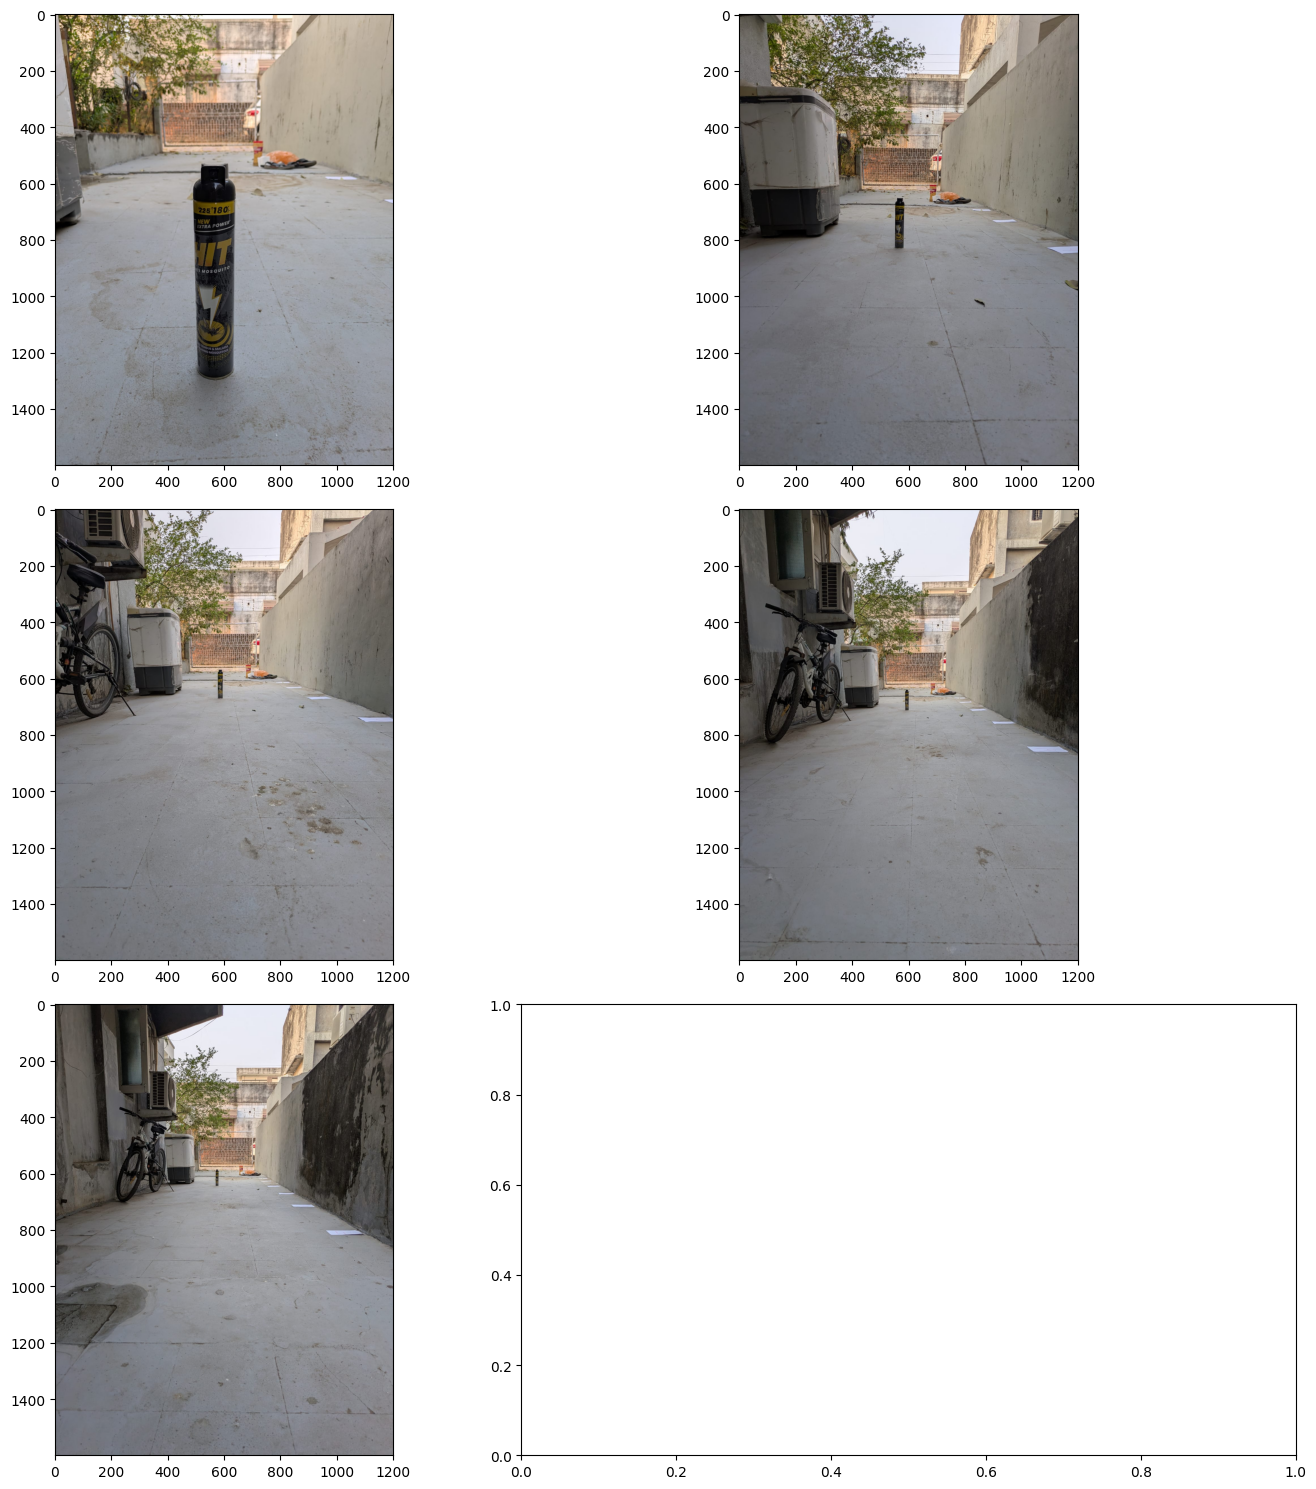

In [302]:
show([closeup] + x4_images)

# Closeup -> x4_images[0]

figsize (5, 5)


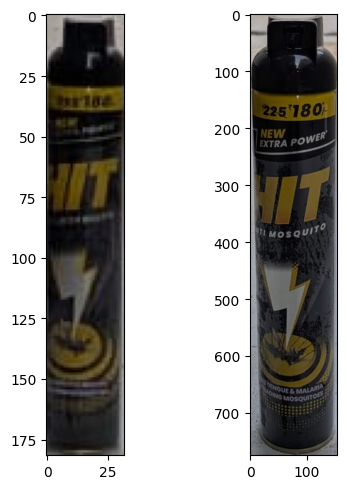

In [303]:
far = x4_images[0][620:860, 520:610]
far_bbox = BBox(y0=30, y1=212, x0=33, x1=65)

near = closeup[400:1500, 300:700]
near_bbox = BBox(y0=125, y1=900, x0=187, x1=340)

show([far[far_bbox], near[near_bbox]])

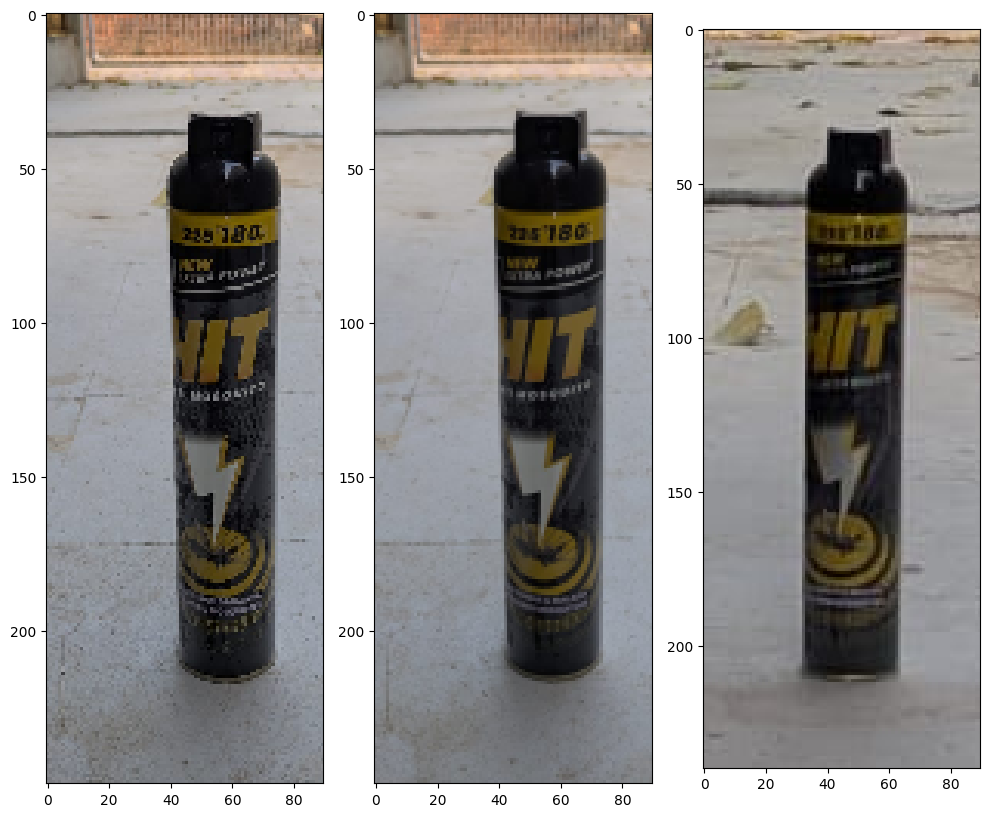

In [ ]:
near_rsz = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_NEAREST)
near_rsz_inter_area = near.resized_to_another(near_bbox, far, far_bbox, cv2.INTER_AREA)
show([near_rsz, near_rsz_inter_area, far], ncols=3, figsize=(10, 10))

- INTER_LINEAR is weird at preserving angled lines. Straight lines are fine, angled lines become jagged.  
- INTER_AREA seems to be doing better, where it blurs the image as well a little at the edges I think.  
We will use INTER_AREA for further analysis



It is clear that the amount of blurring on the overall object is more in the far photo.  
- The bottle of hit itself has a lot of sharp lines (the designs, paintings, etc.).  
- That has made the blur slightly more apparent (although I'm not sure if this will be painful for me to do border analysis).  
Lets take a look at top left edge. 

In [305]:
near_rsz = near_rsz_inter_area

In [306]:
top_left_near = near_rsz[30:60, 35:55]
top_left_far = far[30:65, 30:55]

The left image in the above one has more light falling on the edge.  
It makes it difficult to see how "big" the edge is   
Overall, the colors of both images do look different (because the closeup is taken from a different angle)?  

I'll try taking a look at the right edge then.  

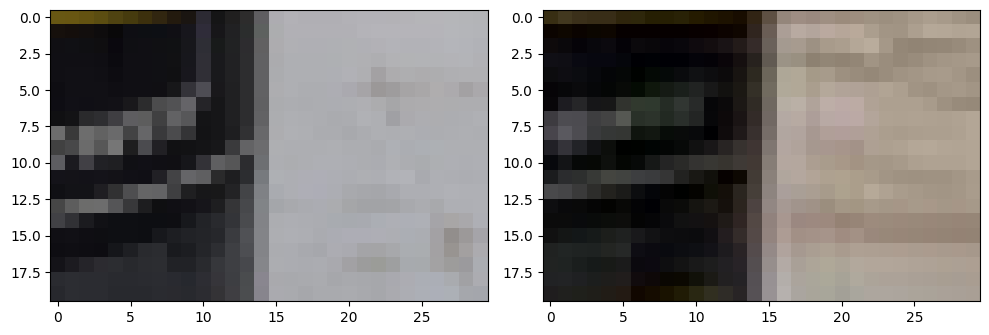

In [ ]:
show([near_rsz[75:95, 60:90], far[70:90, 50:80]], figsize=(10, 10))

Sadly, the background color is different xD. It might be better then to actually look inside the hit bottle to see how the lines in it are changing.  

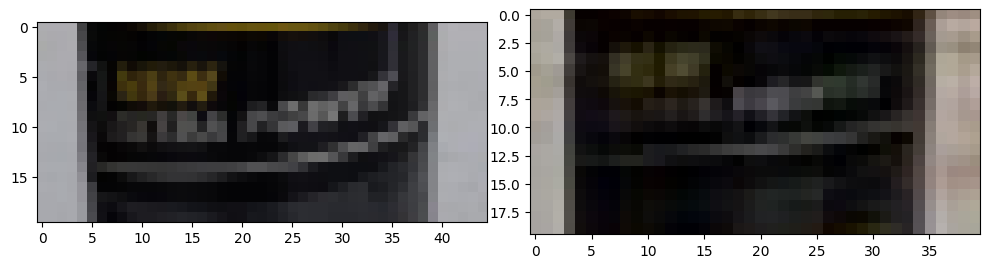

In [ ]:
near_edge = near_rsz[75:95, 35:80]
far_edge = far[70:90, 30:70]
show([near_edge, far_edge], figsize=(10, 10))

Well, there is quite a lot of blur here. Let's run the standard gaussian blur we run normally, and compare. I'm not able to count pixels  

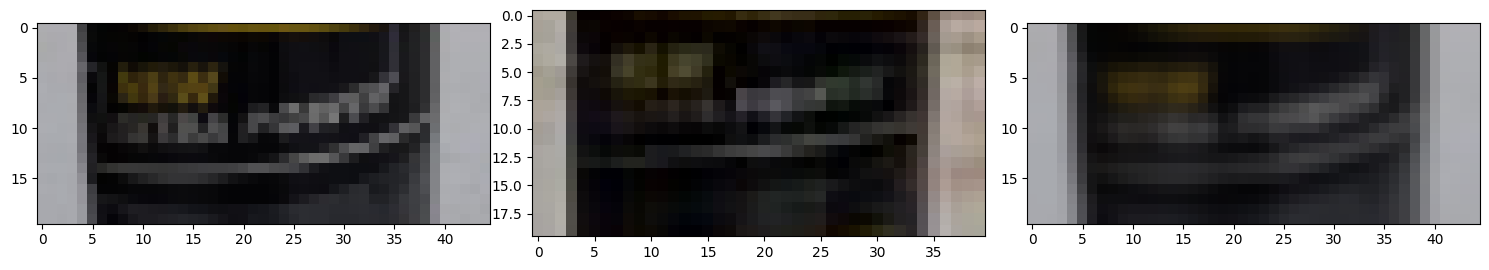

In [ ]:
show(
    [near_edge, far_edge, cv2.GaussianBlur(near_edge.rgb, (3, 3), 1, sigmaY=1)],
    ncols=3,
    figsize=(15, 15),
)

The blur looks more than what I need actually, but this is the minimum gaussian blur I can apply. Let's check it on the whole image

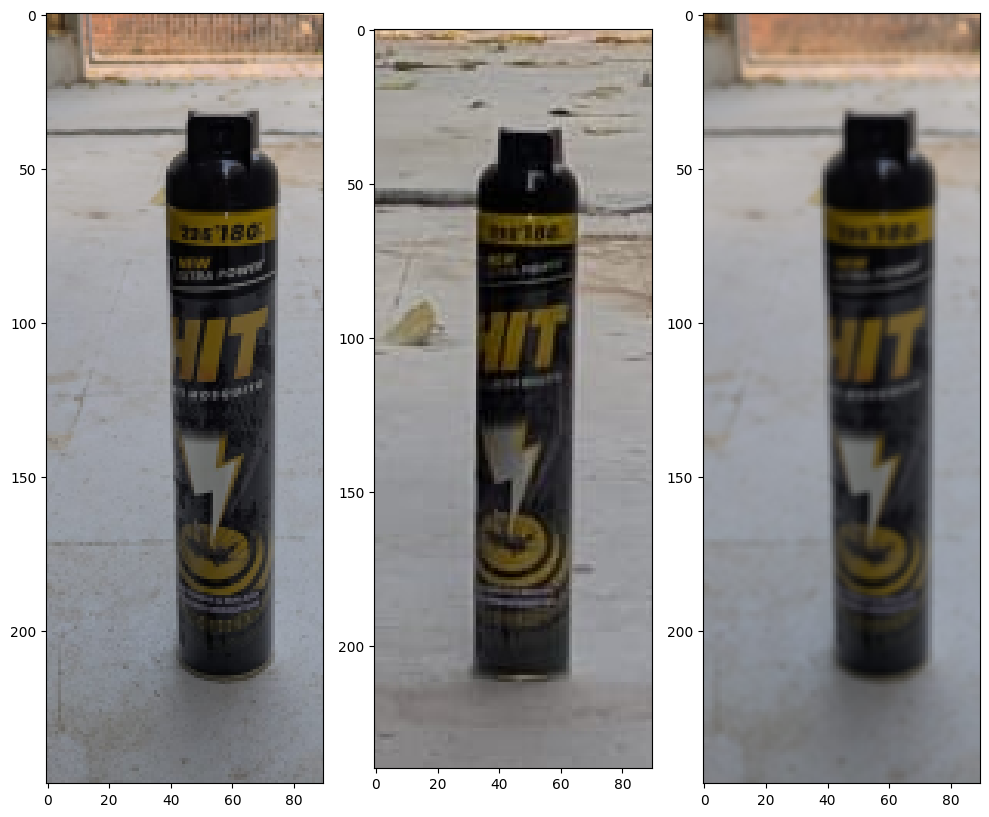

In [ ]:
show(
    [near_rsz, far, cv2.GaussianBlur(near_rsz.rgb, (3, 3), 1, sigmaY=1)],
    ncols=3,
    figsize=(10, 10),
)

We definitely have more blur and I'm not sure if it is the right way to go about it. The gaussian blurred image looks starkly different from the original one too.  

In [ ]:
# lets blur before resizing
# def resized_to_another(self, our_bbox, other, other_bbox, interpolation):
near_blur = ImageAndDist.clone_with_diff_rgb(
    near, cv2.GaussianBlur(near.rgb, (11, 11), 2, sigmaY=2)
)
near_rsz_after_blur = near_blur.resized_to_another(
    near_bbox, far, far_bbox, cv2.INTER_AREA
)

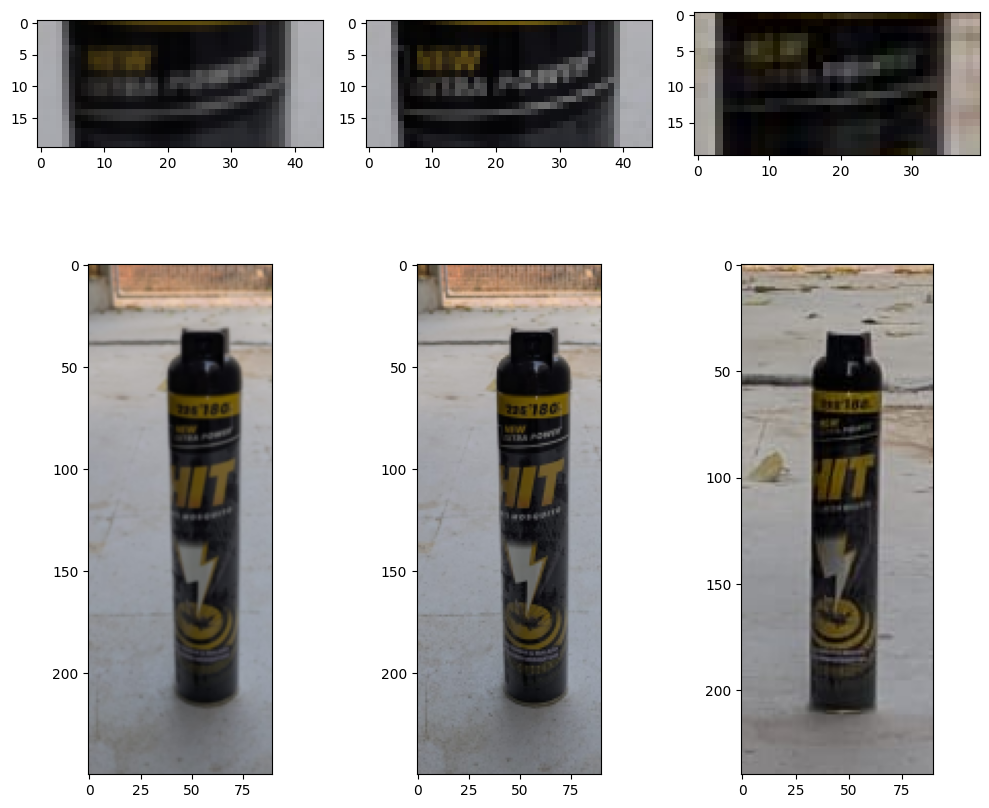

In [ ]:
near_edge = near_rsz[75:95, 35:80]
near_edge_after_blur = near_rsz_after_blur[75:95, 35:80]
far_edge = far[70:90, 30:70]
show(
    [
        near_edge_after_blur,
        near_edge,
        far_edge,
        near_rsz_after_blur,
        near_rsz,
        far,
    ],
    figsize=(10, 10),
    ncols=3,
)

Blur before resize seems better here. Although, I'm still not happy. Let's try plain cv blur.  

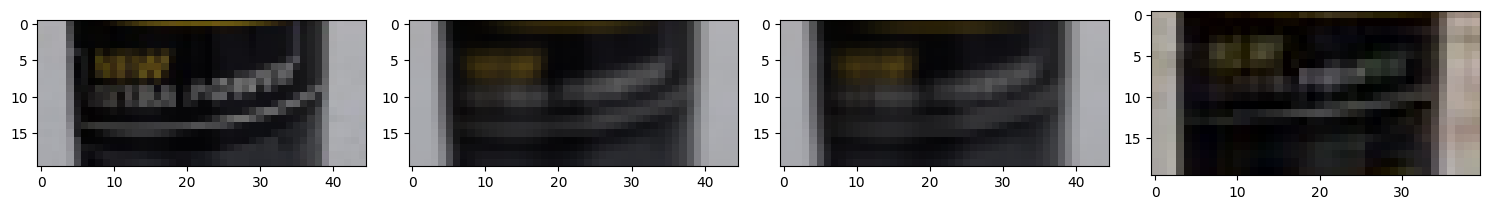

In [355]:
show(
    [
        near_edge.rgb,
        cv2.GaussianBlur(near_edge.rgb, (3,3), 1),
        cv2.blur(near_edge.rgb, (3, 3)),
        far_edge,
    ],
    figsize=(15, 15),
    ncols=4,
)

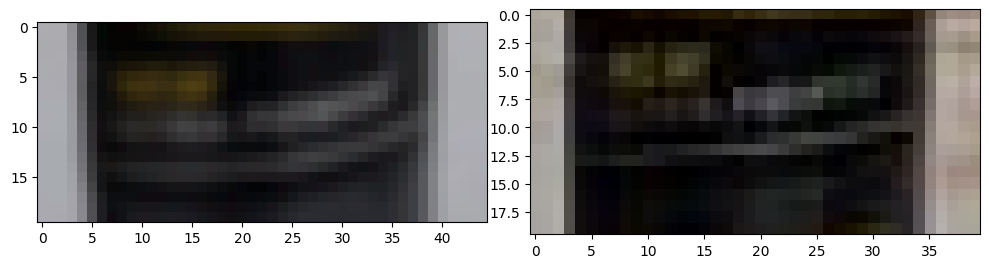

In [ ]:
show(
    [add_luminosity_lab(cv2.GaussianBlur(near_edge.rgb, (3, 3), 1), 0), far_edge],
    figsize=(10, 10),
)

Let's backtrack a bit, I think blurring before resizing and then changing luminosity might help.  
Let's try different sigmas and ks

| k | sigma| res |
|---|------|-----|
| 3 | all sigmas | no change |
| 5 | 1 | compared to 3, i think the number of pixel spread is not increasing, but the brightness of pixel spread is changing (going more towards outside) |
| 5 | all sigmas | no change |


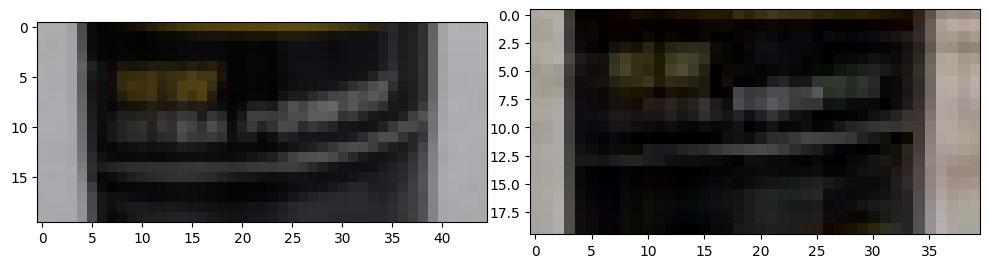

In [416]:
k = 9
sigma = 2
near_blur = ImageAndDist.clone_with_diff_rgb(
    near, cv2.GaussianBlur(near.rgb, (k, k), sigma, sigmaY=sigma)
)
near_rsz_after_blur = near_blur.resized_to_another(
    near_bbox, far, far_bbox, cv2.INTER_AREA
)
near_edge_after_blur = near_rsz_after_blur[75:95, 35:80]
far_edge = far[70:90, 30:70]

show([near_edge_after_blur, far_edge], (10,10))

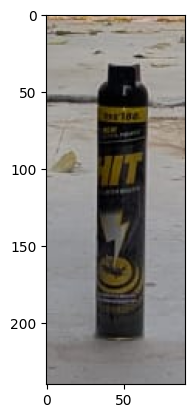

In [418]:
plt.imshow(far.rgb)

figsize (10, 10)


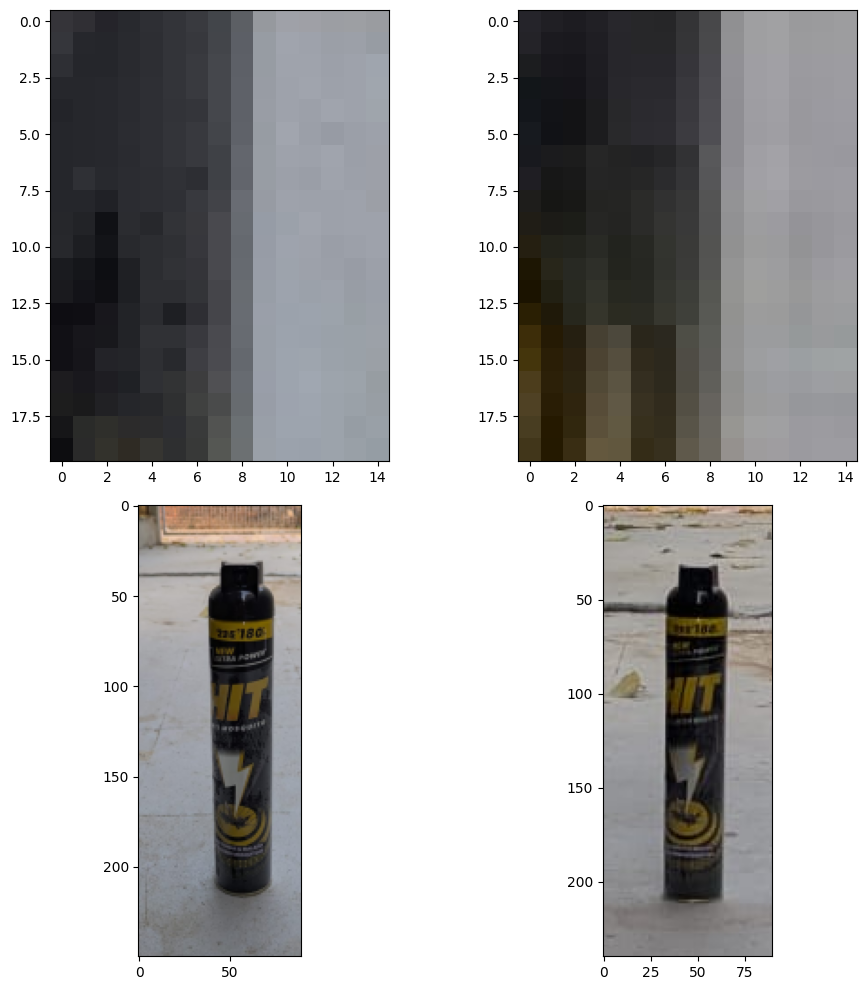

In [436]:
show([near_rsz[150:170, 65:80], far[150:170, 55:70], near_rsz, far])
# plt.imshow(far[150:200, 30:].rgb)

For now giving up on HIT, will come back later. Let's try something else